# Ensemble: Frozen ViT-B/16 + DINOv2 ViT-B/14 PatchCore

Max-fusion score ensemble combining:
- **Frozen ViT-B/16** (supervised ImageNet-21k) - strong on global defects (Edge-Ring 0.941, Edge-Loc 0.705)
- **Frozen DINOv2 ViT-B/14 block 9** (DINO self-distillation, 142M images) - strong on local defects (Scratch 0.933)

**No recomputation.** Both models' scores are loaded from saved `.npz` files. The ensemble requires no GPU.

**Method:** each model's scores are min-max normalised to `[0, 1]` independently using the full
observed score range (tune-normal + test-normal + test-defect). The ensemble score is the
element-wise maximum. Threshold is calibrated at `q=0.95` on the ensemble tune-normal scores.

**Control flags (set in the Configuration cell):**
- `DINOV2_BLOCK` - which DINOv2 block sweep run to load (`9` for best Scratch recall, `6` for best overall DINOv2)
- `FORCE_RERUN_UMAP` - set `True` to rerun UMAP, `False` to display saved figure

## Individual model results (for context)

| Model | F1 | AUROC | AUPRC | Scratch | Edge-Ring | Edge-Loc |
|---|---|---|---|---|---|---|
| Frozen ViT-B/16 | 0.595 | 0.956 | 0.671 | 0.727 | 0.941 | 0.705 |
| DINOv2 block 6 | 0.521 | 0.926 | 0.549 | 0.800 | 0.774 | 0.604 |
| DINOv2 block 9 | 0.492 | 0.915 | 0.561 | **0.933** | 0.738 | 0.547 |
| Ensemble (this) | TBD | TBD | TBD | TBD | TBD | TBD |

## Setup

In [1]:
from importlib.util import find_spec
import sys
deps = [('timm', 'timm'), ('tqdm', 'tqdm')]
missing = [pkg for pkg, module_name in deps if find_spec(module_name) is None]
DEPS_READY = not missing
if DEPS_READY:
    print('deps ready')
else:
    print(f'[WARNING] Missing dependencies: {missing}. This notebook run will skip dependency-backed cells.')


deps ready


## Imports

In [2]:
# -- 1. Imports ----------------------------------------------------------------
import os, gc, json, random, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    f1_score, precision_score, recall_score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

from IPython.display import display, Image as IPImage
print('Imports OK')

Imports OK


## Configuration

Set `DINOV2_BLOCK = 9` for max Scratch recall or `6` for best overall DINOv2 coverage.

In [3]:
# -- 2. Configuration ----------------------------------------------------------
from pathlib import Path

# -- Repo root resolution ------------------------------------------------------
cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / 'src' / 'wafer_defect').exists() and (candidate / 'configs').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate repo root containing src/wafer_defect and configs/')

# -- Control flags -------------------------------------------------------------
# Which DINOv2 block sweep to load:
#   9  - best Scratch recall (0.933) - most complementary to ViT-B/16
#   6  - best overall DINOv2 metrics (AUROC 0.926, F1 0.521)
DINOV2_BLOCK     = 9
FORCE_RERUN_UMAP = False   # True --> rerun UMAP projection

# -- Data ----------------------------------------------------------------------
METADATA_CSV = str(PROJECT_ROOT / 'data' / 'processed' / 'x224' / 'wm811k' / 'metadata_50k_5pct.csv')
TRAIN_NORMAL_N = 40_000
TUNE_NORMAL_N  =  5_000
TEST_NORMAL_N  =  5_000
TEST_DEFECT_N  =    250

# -- Score file paths ----------------------------------------------------------
# Frozen ViT-B/16 baseline (z-scores: keys *_z)
VIT_SCORES_PATH = str(
    PROJECT_ROOT /
    'experiments/anomaly_detection/patchcore/vit_b16/x224'
    '/main/artifacts/patchcore_vit_b16_5pct/main_5pct/results/scores.npz'
)

# DINOv2 block sweep scores (raw distances)
_block_dir = f'block{DINOV2_BLOCK}' if DINOV2_BLOCK == 9 else f'block_{DINOV2_BLOCK}'
DINOV2_SCORES_PATH = str(
    PROJECT_ROOT /
    f'experiments/anomaly_detection/patchcore/dinov2_vit_b14/x224'
    f'/{_block_dir}/artifacts/results/scores.npz'
)

# -- Threshold -----------------------------------------------------------------
THRESHOLD_QUANTILE = 0.95

# -- Artifact paths ------------------------------------------------------------
ARTIFACT_DIR = str(
    PROJECT_ROOT /
    f'experiments/anomaly_detection/patchcore/dinov2_vit_b14/x224'
    f'/ensemble_block{DINOV2_BLOCK}/artifacts'
)
PLOTS_DIR   = os.path.join(ARTIFACT_DIR, 'plots')
RESULTS_DIR = os.path.join(ARTIFACT_DIR, 'results')

SCORES_EXPORT_PATH  = os.path.join(RESULTS_DIR, 'scores.npz')
METRICS_EXPORT_PATH = os.path.join(RESULTS_DIR, 'evaluation_metrics.json')
UMAP_PNG_PATH       = os.path.join(PLOTS_DIR,   'umap_test_embeddings.png')
UMAP_CSV_PATH       = os.path.join(RESULTS_DIR, 'umap_test_embeddings.csv')

for d in [PLOTS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Project root    : {PROJECT_ROOT}')
print(f'ViT-B/16 scores : {VIT_SCORES_PATH}')
print(f'DINOv2 scores   : {DINOV2_SCORES_PATH}')
print(f'DINOv2 block    : {DINOV2_BLOCK}')
print(f'Threshold       : q={THRESHOLD_QUANTILE}')
print(f'Artifacts       : {ARTIFACT_DIR}')

Project root    : C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8
ViT-B/16 scores : C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\vit_b16\x224\main\artifacts\patchcore_vit_b16_5pct\main_5pct\results\scores.npz
DINOv2 scores   : C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\block9\artifacts\results\scores.npz
DINOv2 block    : 9
Threshold       : q=0.95
Artifacts       : C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\ensemble_block9\artifacts


## Load Dataset

Only the test-defect split is needed to recover per-class failure labels. No model inference runs here.

In [4]:
# -- 3. Load dataset (labels only) --------------------------------------------
df = pd.read_csv(METADATA_CSV).copy()

df['failure_label'] = df['defect_type'].astype(str).str.strip()
df['is_anomaly'] = df['is_anomaly'].astype(int)

test_defect_df = (
    df[(df['split'] == 'test') & (df['is_anomaly'] == 1)]
    .head(TEST_DEFECT_N)
    .copy()
)

defect_class_labels = test_defect_df['failure_label'].values
print(f'Test defect class labels recovered: {len(defect_class_labels)} samples')
print(pd.Series(defect_class_labels).value_counts().to_string())


Test defect class labels recovered: 250 samples
Edge-Ring    84
Edge-Loc     53
Center       50
Loc          34
Scratch      15
Donut         7
Random        5
Near-full     2


## Load Scores

Frozen ViT-B/16 scores are stored as z-scores (`(raw - train_mu) / train_std`). DINOv2 scores are raw kNN distances. Both are normalised to `[0, 1]` independently before fusion.

In [5]:
# -- 4. Load scores from disk --------------------------------------------------

# -- Frozen ViT-B/16 (z-scores) ------------------------------------------------
with np.load(VIT_SCORES_PATH) as vit_npz:
    vit_tune   = vit_npz['tune_normal_scores_z'].astype(np.float64)
    vit_normal = vit_npz['test_normal_scores_z'].astype(np.float64)
    vit_defect = vit_npz['test_defect_scores_z'].astype(np.float64)

# -- DINOv2 (raw kNN distances) ------------------------------------------------
with np.load(DINOV2_SCORES_PATH) as d2_npz:
    d2_tune   = d2_npz['tune_normal_scores'].astype(np.float64)
    d2_normal = d2_npz['test_normal_scores'].astype(np.float64)
    d2_defect = d2_npz['test_defect_scores'].astype(np.float64)

assert len(vit_tune)   == len(d2_tune)   == TUNE_NORMAL_N,   'tune-normal size mismatch'
assert len(vit_normal) == len(d2_normal) == TEST_NORMAL_N,   'test-normal size mismatch'
assert len(vit_defect) == len(d2_defect) == TEST_DEFECT_N,   'test-defect size mismatch'

print('Frozen ViT-B/16 z-score ranges:')
print(f'  tune-normal : [{vit_tune.min():.3f}, {vit_tune.max():.3f}]  mean={vit_tune.mean():.3f}')
print(f'  test-normal : [{vit_normal.min():.3f}, {vit_normal.max():.3f}]')
print(f'  test-defect : [{vit_defect.min():.3f}, {vit_defect.max():.3f}]')
print()
print(f'DINOv2 block-{DINOV2_BLOCK} raw distance ranges:')
print(f'  tune-normal : [{d2_tune.min():.4f}, {d2_tune.max():.4f}]  mean={d2_tune.mean():.4f}')
print(f'  test-normal : [{d2_normal.min():.4f}, {d2_normal.max():.4f}]')
print(f'  test-defect : [{d2_defect.min():.4f}, {d2_defect.max():.4f}]')

Frozen ViT-B/16 z-score ranges:
  tune-normal : [-3.552, 6.693]  mean=0.055
  test-normal : [-3.328, 6.275]
  test-defect : [-0.939, 11.235]

DINOv2 block-9 raw distance ranges:
  tune-normal : [0.3851, 0.7017]  mean=0.4608
  test-normal : [0.3772, 0.7274]
  test-defect : [0.4351, 1.1062]


## Normalise and Ensemble

Min-max normalisation uses the global observed range of each model (tune + test-normal + test-defect combined). This maps each model's full dynamic range to `[0, 1]` without leaking test-label information. The ensemble score is `max(vit_norm, dinov2_norm)` - whichever model is more confident flags the image as anomalous.

In [6]:
# -- 5. Min-max normalise each model independently ----------------------------

def minmax_norm(tune, normal, defect):
    """Normalise to [0,1] using global min/max across all score sets."""
    all_scores = np.concatenate([tune, normal, defect])
    lo, hi     = all_scores.min(), all_scores.max()
    scale = hi - lo
    return (tune - lo) / scale, (normal - lo) / scale, (defect - lo) / scale

vit_tune_n,  vit_normal_n,  vit_defect_n  = minmax_norm(vit_tune,  vit_normal,  vit_defect)
d2_tune_n,   d2_normal_n,   d2_defect_n   = minmax_norm(d2_tune,   d2_normal,   d2_defect)

# -- Max-fusion ensemble -------------------------------------------------------
ens_tune   = np.maximum(vit_tune_n,   d2_tune_n)
ens_normal = np.maximum(vit_normal_n, d2_normal_n)
ens_defect = np.maximum(vit_defect_n, d2_defect_n)

# -- Threshold calibrated on ensemble tune-normal ------------------------------
best_thresh = float(np.quantile(ens_tune, THRESHOLD_QUANTILE))

print('Normalised score ranges (each model independently):')
print(f'  ViT-B/16 tune-normal  : [{vit_tune_n.min():.4f}, {vit_tune_n.max():.4f}]')
print(f'  DINOv2 tune-normal    : [{d2_tune_n.min():.4f}, {d2_tune_n.max():.4f}]')
print()
print('Ensemble (max-fusion) score ranges:')
print(f'  tune-normal : [{ens_tune.min():.4f}, {ens_tune.max():.4f}]  mean={ens_tune.mean():.4f}')
print(f'  test-normal : [{ens_normal.min():.4f}, {ens_normal.max():.4f}]')
print(f'  test-defect : [{ens_defect.min():.4f}, {ens_defect.max():.4f}]')
print()
print(f'Threshold (q={THRESHOLD_QUANTILE} on ensemble tune-normal): {best_thresh:.6f}')

Normalised score ranges (each model independently):
  ViT-B/16 tune-normal  : [0.0000, 0.6929]
  DINOv2 tune-normal    : [0.0108, 0.4452]

Ensemble (max-fusion) score ranges:
  tune-normal : [0.0661, 0.6929]  mean=0.2460
  test-normal : [0.0640, 0.6646]
  test-defect : [0.1767, 1.0000]

Threshold (q=0.95 on ensemble tune-normal): 0.356979


## Threshold Calibration

Threshold : 0.356979  (q=0.95)
FPR on tune-normal: 0.0500


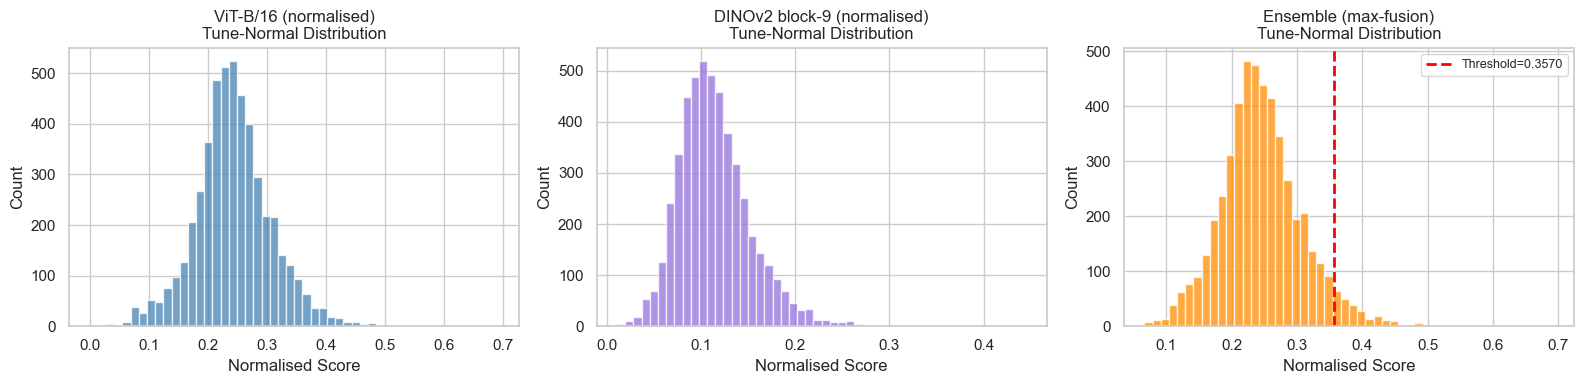

In [7]:
# -- 6. Threshold plot ---------------------------------------------------------
fpr_tune = float((ens_tune > best_thresh).mean())
print(f'Threshold : {best_thresh:.6f}  (q={THRESHOLD_QUANTILE})')
print(f'FPR on tune-normal: {fpr_tune:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, scores, name, color in [
    (axes[0], vit_tune_n,  'ViT-B/16 (normalised)',        'steelblue'),
    (axes[1], d2_tune_n,   f'DINOv2 block-{DINOV2_BLOCK} (normalised)', 'mediumpurple'),
    (axes[2], ens_tune,    'Ensemble (max-fusion)',         'darkorange'),
]:
    ax.hist(scores, bins=50, alpha=0.75, color=color)
    if ax is axes[2]:
        ax.axvline(best_thresh, color='red', linestyle='--', lw=2,
                   label=f'Threshold={best_thresh:.4f}')
        ax.legend(fontsize=9)
    ax.set_title(f'{name}\nTune-Normal Distribution')
    ax.set_xlabel('Normalised Score'); ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'threshold_selection.png'), dpi=140, bbox_inches='tight')
plt.show()

## Evaluate

Overall and per-class metrics for the ensemble. Individual model metrics are printed for direct comparison.

In [8]:
# -- 7. Evaluation -------------------------------------------------------------
all_scores = np.concatenate([ens_normal, ens_defect])
all_labels = np.concatenate([
    np.zeros(len(ens_normal), dtype=int),
    np.ones( len(ens_defect), dtype=int),
])
predictions = (all_scores > best_thresh).astype(int)

roc_auc = roc_auc_score(all_labels, all_scores)
auprc   = average_precision_score(all_labels, all_scores)
fpr_arr, tpr_arr, _         = roc_curve(all_labels, all_scores)
prec_arr, rec_arr, _        = precision_recall_curve(all_labels, all_scores)

f1_val        = f1_score(all_labels, predictions, pos_label=1, zero_division=0)
precision_val = precision_score(all_labels, predictions, pos_label=1, zero_division=0)
recall_val    = recall_score(all_labels, predictions, pos_label=1, zero_division=0)

print('-- Ensemble Test Results -----------------------------')
print(f'ROC-AUC  : {roc_auc:.4f}')
print(f'AUPRC    : {auprc:.4f}')
print(f'Threshold: {best_thresh:.6f}  (q={THRESHOLD_QUANTILE})')
print()
print(classification_report(all_labels, predictions,
                             target_names=['Normal', 'Defect'], digits=4))

# -- Per-class breakdown -------------------------------------------------------
defect_preds = (ens_defect > best_thresh).astype(int)

print('-- Per-class defect recall ---------------------------------------')
print(f'  {"Defect type":<14}  {"N":>5}  {"Detected":>8}  {"Recall":>7}  {"Mean score":>10}')
print('  ' + '-' * 52)

perclass_results = {}
for cls in sorted(np.unique(defect_class_labels)):
    mask       = defect_class_labels == cls
    n          = mask.sum()
    detected   = defect_preds[mask].sum()
    recall     = detected / n
    mean_score = ens_defect[mask].mean()
    perclass_results[cls] = {
        'n': int(n), 'detected': int(detected),
        'recall': float(recall), 'mean_score': float(mean_score),
    }
    print(f'  {cls:<14}  {n:>5}  {detected:>8}  {recall:>6.1%}  {mean_score:>10.4f}')

overall_defect_recall = defect_preds.sum() / len(defect_preds)
print('  ' + '-' * 52)
print(f'  {"ALL DEFECTS":<14}  {len(defect_preds):>5}  {defect_preds.sum():>8}  {overall_defect_recall:>6.1%}')

-- Ensemble Test Results -----------------------------
ROC-AUC  : 0.9665
AUPRC    : 0.7165
Threshold: 0.356979  (q=0.95)

              precision    recall  f1-score   support

      Normal     0.9939    0.9524    0.9727      5000
      Defect     0.4815    0.8840    0.6234       250

    accuracy                         0.9491      5250
   macro avg     0.7377    0.9182    0.7981      5250
weighted avg     0.9695    0.9491    0.9561      5250

-- Per-class defect recall ---------------------------------------
  Defect type         N  Detected   Recall  Mean score
  ----------------------------------------------------
  Center             50        44   88.0%      0.4927
  Donut               7         7  100.0%      0.5201
  Edge-Loc           53        45   84.9%      0.4691
  Edge-Ring          84        75   89.3%      0.4583
  Loc                34        31   91.2%      0.4592
  Near-full           2         2  100.0%      0.4340
  Random              5         5  100.0%      0.4

## Threshold Sweep (Best F1)

Sweeps percentile thresholds derived from `ens_tune` (val-normal) from the 80th to 100th percentile in 0.1-step increments and evaluates F1 on the test set at each threshold. This gives the deployment-aware best achievable F1 - thresholds are calibrated from validation normals only, never from the test set.

-- Threshold sweep (best F1) ----------------------------------
  Best F1        : 0.6760
  At percentile  : 98.6th
  Threshold      : 0.411231
  Precision      : 0.6760
  Recall         : 0.6760

  Val-threshold F1 (q=0.95): 0.6234
  Sweep best F1            : 0.6760


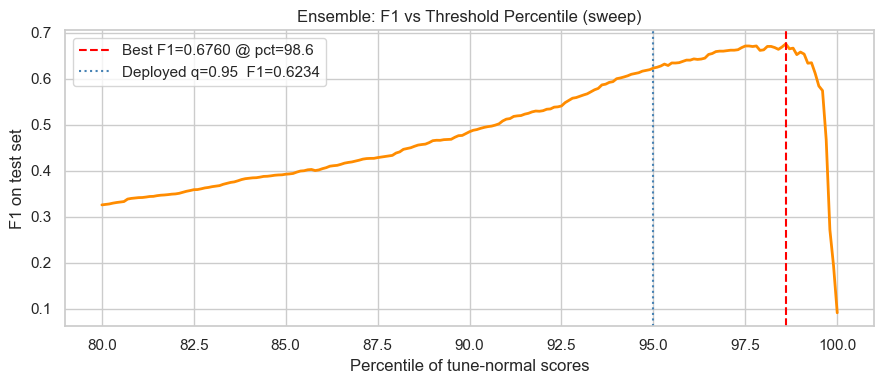

Sweep CSV saved -> C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\ensemble_block9\artifacts\results/threshold_sweep.csv


In [9]:
# -- 7b. Threshold sweep -------------------------------------------------------
sweep_rows = []
for pct in np.arange(80, 100.1, 0.1):
    thr  = float(np.percentile(ens_tune, pct))
    pred = (all_scores >= thr).astype(int)
    tp   = int(((pred == 1) & (all_labels == 1)).sum())
    fp   = int(((pred == 1) & (all_labels == 0)).sum())
    fn   = int(((pred == 0) & (all_labels == 1)).sum())
    prec = tp / max(1, tp + fp)
    rec  = tp / max(1, tp + fn)
    f1   = 0.0 if prec + rec == 0 else 2 * prec * rec / (prec + rec)
    sweep_rows.append({'percentile': round(pct, 1), 'threshold': thr,
                       'precision': prec, 'recall': rec, 'f1': f1})

sweep_df   = pd.DataFrame(sweep_rows)
best_sweep = sweep_df.loc[sweep_df['f1'].idxmax()]

print('-- Threshold sweep (best F1) ----------------------------------')
print(f'  Best F1        : {best_sweep["f1"]:.4f}')
print(f'  At percentile  : {best_sweep["percentile"]:.1f}th')
print(f'  Threshold      : {best_sweep["threshold"]:.6f}')
print(f'  Precision      : {best_sweep["precision"]:.4f}')
print(f'  Recall         : {best_sweep["recall"]:.4f}')
print()
print(f'  Val-threshold F1 (q=0.95): {f1_val:.4f}')
print(f'  Sweep best F1            : {best_sweep["f1"]:.4f}')

# Plot sweep curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sweep_df['percentile'], sweep_df['f1'], color='darkorange', lw=2)
ax.axvline(best_sweep['percentile'], color='red', linestyle='--', lw=1.5,
           label=f'Best F1={best_sweep["f1"]:.4f} @ pct={best_sweep["percentile"]:.1f}')
ax.axvline(THRESHOLD_QUANTILE * 100, color='steelblue', linestyle=':', lw=1.5,
           label=f'Deployed q=0.95  F1={f1_val:.4f}')
ax.set_xlabel('Percentile of tune-normal scores')
ax.set_ylabel('F1 on test set')
ax.set_title('Ensemble: F1 vs Threshold Percentile (sweep)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'threshold_sweep.png'), dpi=130, bbox_inches='tight')
plt.show()

sweep_df.to_csv(os.path.join(RESULTS_DIR, 'threshold_sweep.csv'), index=False)
print(f'Sweep CSV saved -> {RESULTS_DIR}/threshold_sweep.csv')

## Comparison Table

All models side-by-side.

In [10]:
# -- 8. Comparison table -------------------------------------------------------

# -- Also evaluate each individual model at its own threshold for comparison ---
# ViT-B/16 at its own threshold (q=0.95 on its tune-normal normalised)
vit_thresh  = float(np.quantile(vit_tune_n, THRESHOLD_QUANTILE))
d2_thresh   = float(np.quantile(d2_tune_n,  THRESHOLD_QUANTILE))

def eval_model(normal_scores, defect_scores, thresh):
    all_s = np.concatenate([normal_scores, defect_scores])
    all_l = np.concatenate([np.zeros(len(normal_scores)), np.ones(len(defect_scores))])
    preds = (all_s > thresh).astype(int)
    return {
        'AUROC': roc_auc_score(all_l, all_s),
        'AUPRC': average_precision_score(all_l, all_s),
        'F1':    f1_score(all_l, preds, pos_label=1, zero_division=0),
    }

vit_m  = eval_model(vit_normal_n,  vit_defect_n,  vit_thresh)
d2_m   = eval_model(d2_normal_n,   d2_defect_n,   d2_thresh)
ens_m  = {'AUROC': roc_auc, 'AUPRC': auprc, 'F1': f1_val}

# -- Per-class recall for comparison ------------------------------------------
def perclass_recall(defect_scores, thresh):
    preds = (defect_scores > thresh).astype(int)
    out = {}
    for cls in sorted(np.unique(defect_class_labels)):
        mask = defect_class_labels == cls
        out[cls] = preds[mask].sum() / mask.sum()
    return out

vit_pc  = perclass_recall(vit_defect_n,  vit_thresh)
d2_pc   = perclass_recall(d2_defect_n,   d2_thresh)
ens_pc  = {c: v['recall'] for c, v in perclass_results.items()}

# -- Print table ---------------------------------------------------------------
models = [
    (f'Frozen ViT-B/16 (reprod.)',     vit_m,  vit_pc),
    (f'DINOv2 block-{DINOV2_BLOCK}',  d2_m,   d2_pc),
    (f'Ensemble (max-fusion)',          ens_m,  ens_pc),
]

all_classes = sorted(np.unique(defect_class_labels))

header = f'{"Model":<32}  {"AUROC":>7}  {"AUPRC":>7}  {"F1":>7}  '
header += '  '.join(f'{c[:8]:>8}' for c in all_classes)
print(header)
print('-' * len(header))
for name, m, pc in models:
    row = f'{name:<32}  {m["AUROC"]:>7.4f}  {m["AUPRC"]:>7.4f}  {m["F1"]:>7.4f}  '
    row += '  '.join(f'{pc.get(c, float("nan")):>8.3f}' for c in all_classes)
    print(row)

# -- DataFrame version ---------------------------------------------------------
rows = []
for name, m, pc in models:
    row = {'Model': name, **m, **{c: round(pc.get(c, float('nan')), 3) for c in all_classes}}
    rows.append(row)
compare_df = pd.DataFrame(rows).set_index('Model')
display(compare_df.round(4))

compare_df.to_csv(os.path.join(RESULTS_DIR, 'model_comparison.csv'))
print(f'Comparison table saved -> {RESULTS_DIR}/model_comparison.csv')

Model                               AUROC    AUPRC       F1    Center     Donut  Edge-Loc  Edge-Rin       Loc  Near-ful    Random   Scratch
-------------------------------------------------------------------------------------------------------------------------------------------
Frozen ViT-B/16 (reprod.)          0.9563   0.6709   0.5951     0.820     1.000     0.792     0.893     0.794     1.000     0.800     0.667
DINOv2 block-9                     0.9147   0.5609   0.4921     0.560     1.000     0.547     0.738     0.706     1.000     1.000     0.933
Ensemble (max-fusion)              0.9665   0.7165   0.6234     0.880     1.000     0.849     0.893     0.912     1.000     1.000     0.800


,AUROC,AUPRC,F1,Center,Donut,Edge-Loc,Edge-Ring,Loc,Near-full,Random,Scratch
Model,,,,,,,,,,,
Frozen ViT-B/16 (reprod.),0.9563,0.6709,0.5951,0.82,1.0,0.792,0.893,0.794,1.0,0.8,0.667
DINOv2 block-9,0.9147,0.5609,0.4921,0.56,1.0,0.547,0.738,0.706,1.0,1.0,0.933
Ensemble (max-fusion),0.9665,0.7165,0.6234,0.88,1.0,0.849,0.893,0.912,1.0,1.0,0.800


Comparison table saved -> C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\ensemble_block9\artifacts\results/model_comparison.csv


## Evaluation Plots

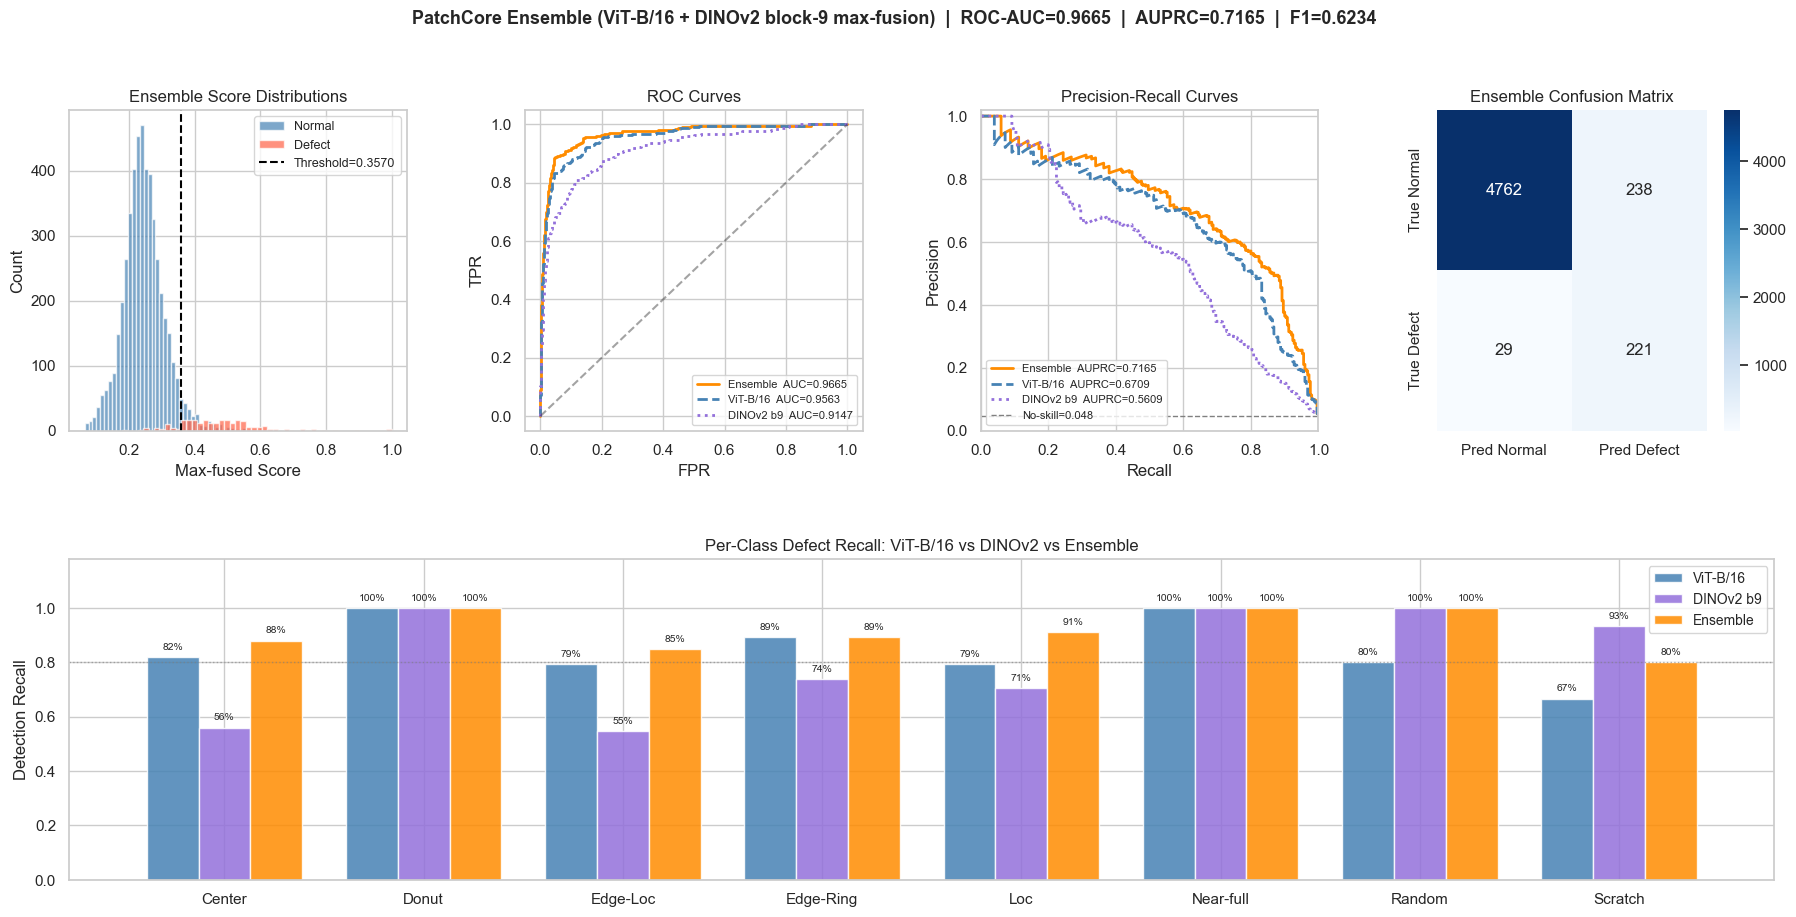

,failure_label,n,detected,recall,mean_score
0,Scratch,15,12,0.800000,0.528995
1,Edge-Loc,53,45,0.849057,0.469094
2,Center,50,44,0.880000,0.492736
3,Edge-Ring,84,75,0.892857,0.458342
4,Loc,34,31,0.911765,0.459209
5,Donut,7,7,1.000000,0.520142
6,Near-full,2,2,1.000000,0.433955
7,Random,5,5,1.000000,0.428722


In [11]:
# -- 9. Evaluation plots -------------------------------------------------------
fig = plt.figure(figsize=(22, 10))
gs  = fig.add_gridspec(2, 4, hspace=0.4, wspace=0.35)

ax_dist = fig.add_subplot(gs[0, 0])
ax_roc  = fig.add_subplot(gs[0, 1])
ax_pr   = fig.add_subplot(gs[0, 2])
ax_cm   = fig.add_subplot(gs[0, 3])
ax_pc   = fig.add_subplot(gs[1, :])

# Score distributions
ax_dist.hist(ens_normal, bins=50, alpha=0.7, color='steelblue', label='Normal')
ax_dist.hist(ens_defect, bins=50, alpha=0.7, color='tomato',    label='Defect')
ax_dist.axvline(best_thresh, color='black', linestyle='--',
                label=f'Threshold={best_thresh:.4f}')
ax_dist.set_title('Ensemble Score Distributions')
ax_dist.set_xlabel('Max-fused Score'); ax_dist.set_ylabel('Count'); ax_dist.legend(fontsize=9)

# ROC curve: ensemble vs individual models
for scores_n, scores_d, label, color, ls in [
    (ens_normal,  ens_defect,  f'Ensemble  AUC={roc_auc:.4f}',     'darkorange',   '-'),
    (vit_normal_n, vit_defect_n, f'ViT-B/16  AUC={vit_m["AUROC"]:.4f}', 'steelblue', '--'),
    (d2_normal_n,  d2_defect_n,  f'DINOv2 b{DINOV2_BLOCK}  AUC={d2_m["AUROC"]:.4f}', 'mediumpurple', ':'),
]:
    all_s = np.concatenate([scores_n, scores_d])
    all_l = np.concatenate([np.zeros(len(scores_n)), np.ones(len(scores_d))])
    fpr_i, tpr_i, _ = roc_curve(all_l, all_s)
    ax_roc.plot(fpr_i, tpr_i, color=color, lw=2, linestyle=ls, label=label)
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_title('ROC Curves')
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR'); ax_roc.legend(fontsize=8)

# PR curve: ensemble vs individual
baseline_pr = all_labels.mean()
for scores_n, scores_d, label, color, ls in [
    (ens_normal,  ens_defect,  f'Ensemble  AUPRC={auprc:.4f}',          'darkorange',   '-'),
    (vit_normal_n, vit_defect_n, f'ViT-B/16  AUPRC={vit_m["AUPRC"]:.4f}', 'steelblue', '--'),
    (d2_normal_n,  d2_defect_n,  f'DINOv2 b{DINOV2_BLOCK}  AUPRC={d2_m["AUPRC"]:.4f}', 'mediumpurple', ':'),
]:
    all_s = np.concatenate([scores_n, scores_d])
    all_l = np.concatenate([np.zeros(len(scores_n)), np.ones(len(scores_d))])
    p_i, r_i, _ = precision_recall_curve(all_l, all_s)
    ax_pr.plot(r_i, p_i, color=color, lw=2, linestyle=ls, label=label)
ax_pr.axhline(baseline_pr, color='gray', linestyle='--', lw=1, label=f'No-skill={baseline_pr:.3f}')
ax_pr.set_title('Precision-Recall Curves')
ax_pr.set_xlabel('Recall'); ax_pr.set_ylabel('Precision')
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.02); ax_pr.legend(fontsize=8)

# Confusion matrix
cm = confusion_matrix(all_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Normal', 'Pred Defect'],
            yticklabels=['True Normal', 'True Defect'], ax=ax_cm)
ax_cm.set_title('Ensemble Confusion Matrix')

# Per-class recall comparison (grouped bars)
classes     = all_classes
x           = np.arange(len(classes))
width       = 0.26

ens_recs = [ens_pc.get(c, 0)       for c in classes]
vit_recs = [vit_pc.get(c, 0)       for c in classes]
d2_recs  = [d2_pc.get(c, 0)        for c in classes]

ax_pc.bar(x - width, vit_recs,  width, label=f'ViT-B/16',          color='steelblue',   alpha=0.85)
ax_pc.bar(x,         d2_recs,   width, label=f'DINOv2 b{DINOV2_BLOCK}', color='mediumpurple', alpha=0.85)
ax_pc.bar(x + width, ens_recs,  width, label='Ensemble',            color='darkorange',  alpha=0.85)

ax_pc.set_xticks(x); ax_pc.set_xticklabels(classes, rotation=0)
ax_pc.set_ylim(0, 1.18); ax_pc.set_ylabel('Detection Recall')
ax_pc.set_title('Per-Class Defect Recall: ViT-B/16 vs DINOv2 vs Ensemble')
ax_pc.axhline(0.8, color='gray', linestyle=':', lw=1, alpha=0.6)
ax_pc.legend(fontsize=10)

for i, (vr, dr, er) in enumerate(zip(vit_recs, d2_recs, ens_recs)):
    for offset, val in [(-width, vr), (0, dr), (width, er)]:
        ax_pc.text(i + offset, val + 0.02, f'{val:.0%}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle(
    f'PatchCore Ensemble (ViT-B/16 + DINOv2 block-{DINOV2_BLOCK} max-fusion)  |  '
    f'ROC-AUC={roc_auc:.4f}  |  AUPRC={auprc:.4f}  |  F1={f1_val:.4f}',
    fontsize=13, fontweight='bold',
)
plt.savefig(os.path.join(PLOTS_DIR, 'evaluation_results.png'), dpi=130, bbox_inches='tight')
plt.show()

# Save defect recall CSV
defect_recall_df = pd.DataFrame([
    {'failure_label': c, **v} for c, v in perclass_results.items()
]).sort_values('recall').reset_index(drop=True)
defect_recall_df.to_csv(os.path.join(RESULTS_DIR, 'defect_recall.csv'), index=False)
display(defect_recall_df)

## UMAP Visualization

Projects ensemble scores into 2D using UMAP on the concatenated normalised score vectors `[vit_norm, dinov2_norm]` for each test image. This shows how the two models' signals combine in score space.

Displaying saved UMAP: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\ensemble_block9\artifacts\plots\umap_test_embeddings.png


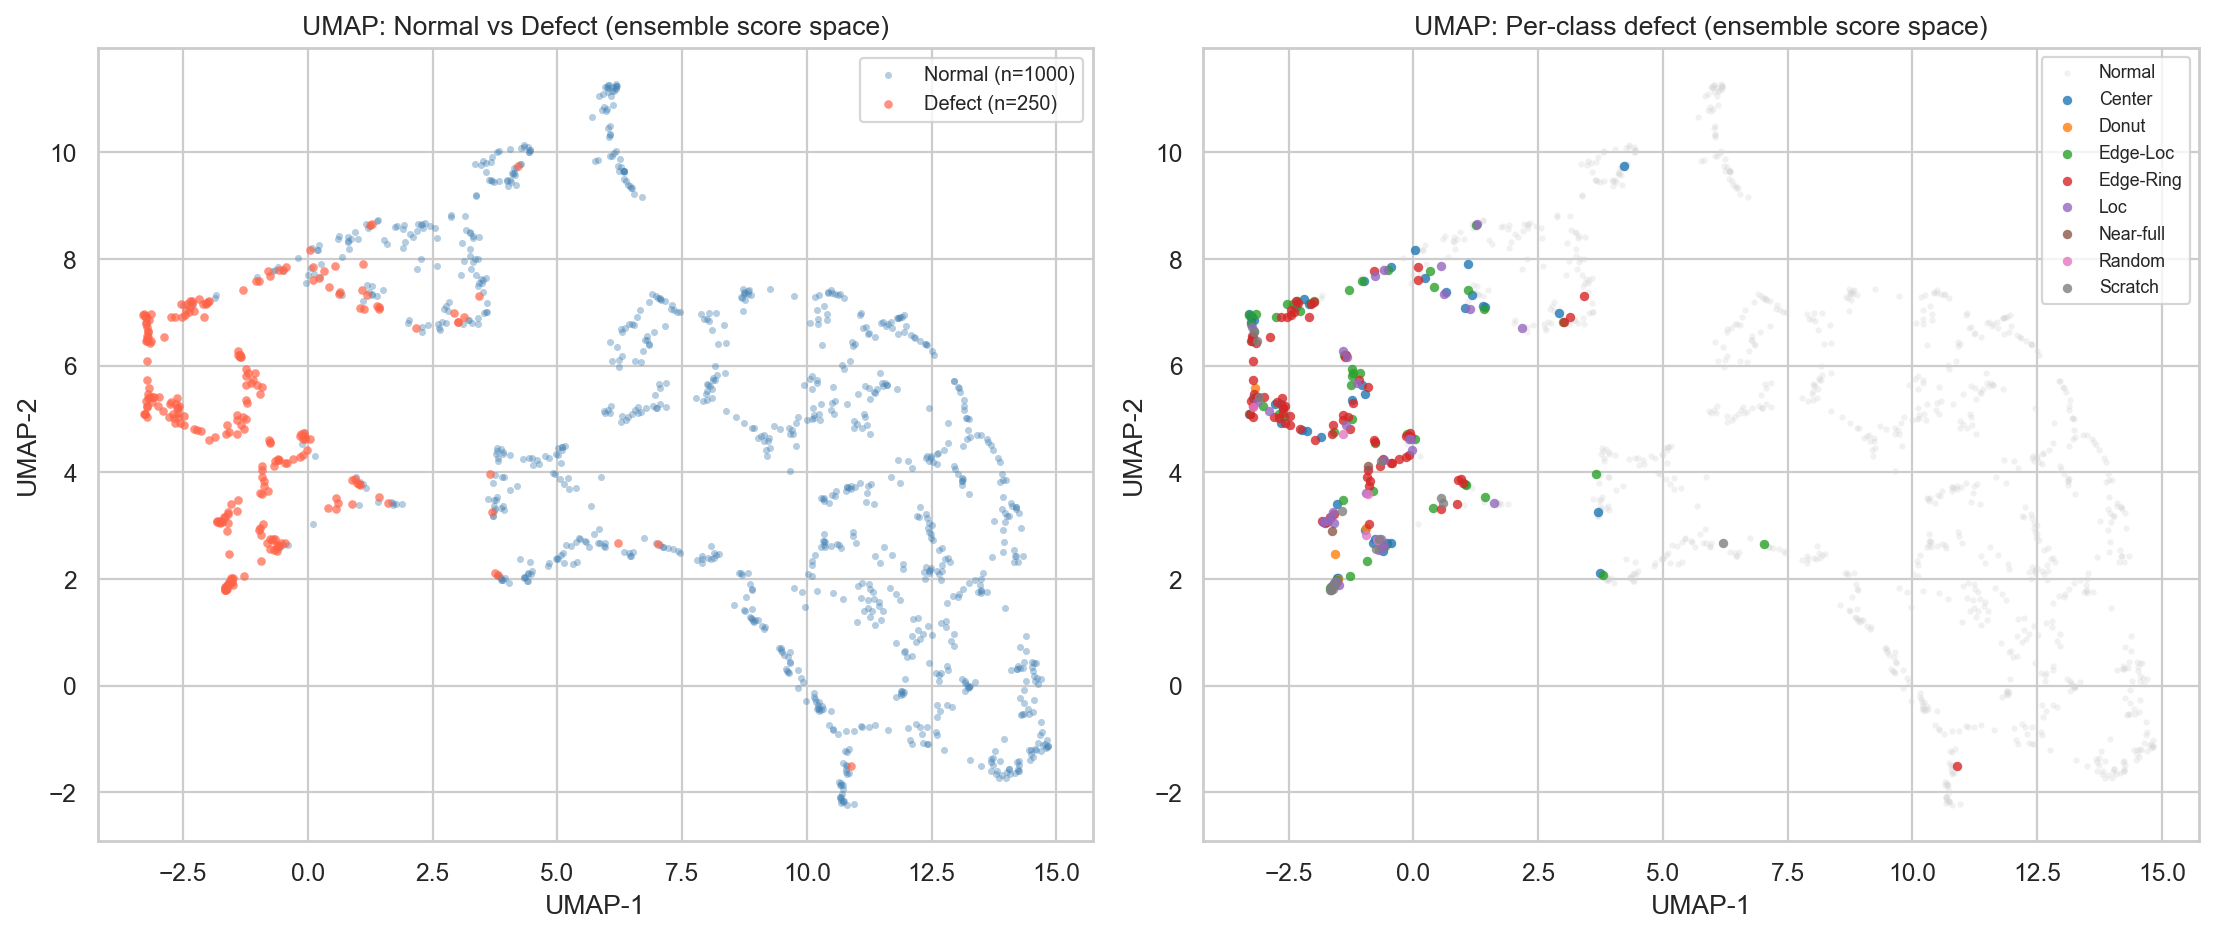

In [12]:
# -- 10. UMAP on 2D score space ------------------------------------------------
if (not FORCE_RERUN_UMAP) and os.path.exists(UMAP_PNG_PATH):
    print(f'Displaying saved UMAP: {UMAP_PNG_PATH}')
    display(IPImage(filename=UMAP_PNG_PATH))
else:
    try:
        import umap.umap_ as umap_lib
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'])
        import umap.umap_ as umap_lib

    # 2-D feature: [normalised_vit_score, normalised_dinov2_score] per image
    X_normal = np.column_stack([vit_normal_n, d2_normal_n])  # [5000, 2]
    X_defect = np.column_stack([vit_defect_n, d2_defect_n])  # [250,  2]

    # Subsample normals to balance
    MAX_NORMAL_UMAP = 1000
    idx_n = np.random.choice(len(X_normal), min(MAX_NORMAL_UMAP, len(X_normal)), replace=False)
    X = np.concatenate([X_normal[idx_n], X_defect])
    y = np.concatenate([np.zeros(len(idx_n)), np.ones(len(X_defect))]).astype(int)
    y_class = np.concatenate([
        np.array(['Normal'] * len(idx_n)),
        defect_class_labels,
    ])

    reducer = umap_lib.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                            metric='euclidean', random_state=SEED, transform_seed=SEED,
                            low_memory=True, verbose=False)
    coords = reducer.fit_transform(X)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: normal vs defect
    m0, m1 = (y == 0), (y == 1)
    axes[0].scatter(coords[m0, 0], coords[m0, 1], s=10, alpha=0.4,
                    c='steelblue', label=f'Normal (n={m0.sum()})', linewidths=0)
    axes[0].scatter(coords[m1, 0], coords[m1, 1], s=15, alpha=0.7,
                    c='tomato', label=f'Defect (n={m1.sum()})', linewidths=0)
    axes[0].set_title('UMAP: Normal vs Defect (ensemble score space)')
    axes[0].set_xlabel('UMAP-1'); axes[0].set_ylabel('UMAP-2'); axes[0].legend(fontsize=9)

    # Right: per-class
    palette = sns.color_palette('tab10', n_colors=len(np.unique(y_class[y == 1])))
    axes[1].scatter(coords[m0, 0], coords[m0, 1], s=8, alpha=0.3,
                    c='lightgray', label='Normal', linewidths=0)
    for col, cls in zip(palette, sorted(np.unique(y_class[y == 1]))):
        mask_cls = (y_class == cls)
        axes[1].scatter(coords[mask_cls, 0], coords[mask_cls, 1],
                        s=18, alpha=0.8, c=[col], label=cls, linewidths=0)
    axes[1].set_title('UMAP: Per-class defect (ensemble score space)')
    axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
    axes[1].legend(fontsize=8, loc='best')

    plt.tight_layout()
    fig.savefig(UMAP_PNG_PATH, dpi=160, bbox_inches='tight')
    plt.show()

    pd.DataFrame({
        'umap_1': coords[:, 0], 'umap_2': coords[:, 1],
        'label': y, 'class': y_class,
    }).to_csv(UMAP_CSV_PATH, index=False)
    print(f'UMAP saved: {UMAP_PNG_PATH}')

## Save Artifacts

In [13]:
# -- 11. Save artifacts --------------------------------------------------------
np.savez_compressed(
    SCORES_EXPORT_PATH,
    tune_normal_scores  = ens_tune,
    test_normal_scores  = ens_normal,
    test_defect_scores  = ens_defect,
    vit_tune_norm       = vit_tune_n,
    vit_normal_norm     = vit_normal_n,
    vit_defect_norm     = vit_defect_n,
    d2_tune_norm        = d2_tune_n,
    d2_normal_norm      = d2_normal_n,
    d2_defect_norm      = d2_defect_n,
    threshold           = np.array(best_thresh),
)
print(f'Scores saved -> {SCORES_EXPORT_PATH}')

metrics = dict(
    ensemble_method      = 'max_fusion_minmax_norm',
    dinov2_block         = DINOV2_BLOCK,
    roc_auc              = float(roc_auc),
    auprc                = float(auprc),
    f1_defect            = float(f1_val),
    precision_defect     = float(precision_val),
    recall_defect        = float(recall_val),
    threshold            = float(best_thresh),
    threshold_quantile   = float(THRESHOLD_QUANTILE),
    confusion_matrix     = cm.tolist(),
    n_test_normal        = int(len(ens_normal)),
    n_test_defect        = int(len(ens_defect)),
    per_class            = perclass_results,
)
with open(METRICS_EXPORT_PATH, 'w') as fh:
    json.dump(metrics, fh, indent=2)
print(f'Metrics saved -> {METRICS_EXPORT_PATH}')

print(f'\nROC-AUC : {roc_auc:.4f}')
print(f'AUPRC   : {auprc:.4f}')
print(f'F1      : {f1_val:.4f}')

Scores saved -> C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\ensemble_block9\artifacts\results\scores.npz
Metrics saved -> C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\ensemble_block9\artifacts\results\evaluation_metrics.json

ROC-AUC : 0.9665
AUPRC   : 0.7165
F1      : 0.6234


## LR Meta-Learner (Stacking Ensemble)

A logistic regression meta-learner learns the optimal decision boundary in the 2D normalised score space `[vit_norm, dinov2_norm]`.

**Clean split.** To keep the 5k/250 test set and 70k/3.5k holdout set completely untouched by training, the LR positives come from the first 350 holdout defects (a slice that is separate from both the 250 test defects and the 3,150 holdout eval defects). Negatives are the 5k tune-normal samples.

**Two variants** are trained: `LR(balanced)` uses sklearn's balanced class weight matching the 14:1 training ratio; `LR(20:1)` sets the weight to match the 70k:3.5k holdout deployment ratio. See evaluation cells in the Holdout section below.

## Holdout Evaluation (70k normal / 3.5k defect)

Runs DINOv2 ViT-B/14 inference on the expanded holdout set, then ensembles with the pre-saved frozen ViT-B/16 holdout scores. The wafer split uses the same `pandas .sample(random_state=42)` ordering as the frozen ViT so that per-wafer scores are aligned.

Set `FORCE_RERUN_HOLDOUT = True` to rerun DINOv2 inference (requires GPU). Set `False` to load previously saved holdout scores.

In [14]:
# -- H1. DINOv2 holdout inference ----------------------------------------------
import pickle, torch, torch.nn as nn, torch.nn.functional as F_nn
from torch.utils.data import DataLoader, Dataset as TorchDataset
from tqdm.auto import tqdm
import pandas.core.indexes as _core_indexes

FORCE_RERUN_HOLDOUT  = False   # True -> re-run DINOv2 inference on 70k+3.5k wafers
HOLDOUT_NORMAL_N     = 70_000
HOLDOUT_DEFECT_N     =  3_500

# -- Paths ----------------------------------------------------------------------
DINO_CKPT_PATH = str(
    PROJECT_ROOT /
    f'experiments/anomaly_detection/patchcore/dinov2_vit_b14/x224'
    f'/block{DINOV2_BLOCK}/artifacts/checkpoints/patchcore_dinov2_model.pt'
)
VIT_HOLDOUT_PATH = str(
    PROJECT_ROOT /
    'experiments/anomaly_detection/patchcore/vit_b16/x224/main'
    '/artifacts/patchcore_vit_b16_5pct/holdout70k_3p5k/scores.npz'
)
DINO_HOLDOUT_SCORES_PATH = os.path.join(RESULTS_DIR, 'dinov2_holdout_scores.npz')
HOLDOUT_RESULTS_DIR = os.path.join(ARTIFACT_DIR, 'results', 'holdout')
os.makedirs(HOLDOUT_RESULTS_DIR, exist_ok=True)

# -- Run or load DINOv2 holdout scores -----------------------------------------
if (not FORCE_RERUN_HOLDOUT) and os.path.exists(DINO_HOLDOUT_SCORES_PATH):
    print(f'Loading saved DINOv2 holdout scores: {DINO_HOLDOUT_SCORES_PATH}')
    _h = np.load(DINO_HOLDOUT_SCORES_PATH, allow_pickle=True)
    h_dino_normal        = _h['holdout_normal_scores']
    h_dino_defect        = _h['holdout_defect_scores']
    h_dino_defect_labels = _h['holdout_defect_labels'].astype(str)
    print(f'  Normal : {h_dino_normal.shape}  mean={h_dino_normal.mean():.4f}')
    print(f'  Defect : {h_dino_defect.shape}  mean={h_dino_defect.mean():.4f}')

else:
    import timm
    DEVICE_H = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Running DINOv2 holdout inference on {DEVICE_H}')

    # -- DINOv2 extractor ------------------------------------------------------
    # img_size=224 is required: timm defaults to 518x518 for this model,
    # giving pos_embed [1, 1370, 768] vs the checkpoint's [1, 257, 768].
    class DINOv2PatchExtractor(nn.Module):
        def __init__(self, block_idx=9, proj_dim=128):
            super().__init__()
            self.vit = timm.create_model(
                'vit_base_patch14_dinov2.lvd142m',
                pretrained=True, num_classes=0, img_size=224)
            self._feat = None
            self.vit.blocks[block_idx].register_forward_hook(
                lambda m, i, o: setattr(self, '_feat', o))
            self.proj = nn.Linear(self.vit.embed_dim, proj_dim, bias=False)
        def forward(self, x):
            self.vit(x)
            return self._feat[:, 1:, :]   # drop CLS -> [B, 256, 768]

    ckpt = torch.load(DINO_CKPT_PATH, map_location='cpu', weights_only=False)
    extractor_h = DINOv2PatchExtractor(block_idx=DINOV2_BLOCK).to(DEVICE_H).eval()
    extractor_h.load_state_dict(ckpt['extractor_state'])
    for p in extractor_h.parameters():
        p.requires_grad_(False)
    mem_bank_h = F_nn.normalize(ckpt['memory_bank'].float(), p=2, dim=1).to(DEVICE_H)
    print(f'Memory bank : {mem_bank_h.shape}')

    # -- PatchCore scoring -----------------------------------------------------
    def _score_batch(xb, extractor, mem_bank, k=3, topk_ratio=0.1, chunk=512):
        B = xb.shape[0]
        with torch.inference_mode():
            feats = extractor(xb)                                     # [B, 256, 768]
            proj  = F_nn.normalize(
                extractor.proj(feats.reshape(-1, feats.shape[-1])),
                p=2, dim=1)                                           # [B*256, 128]
        flat    = proj.reshape(-1, 128)
        bank_t  = mem_bank.t().contiguous()
        results = []
        for s in range(0, flat.shape[0], chunk):
            sim  = flat[s:s+chunk] @ bank_t
            best = sim.topk(k=k, dim=1).values
            dist = torch.sqrt(torch.clamp(2.0 - 2.0 * best, min=0.0)).mean(dim=1)
            results.append(dist)
        patch_dist = torch.cat(results).reshape(B, 256)
        n_topk = max(1, int(round(256 * topk_ratio)))
        return torch.topk(patch_dist, k=n_topk, dim=1).values.mean(dim=1).cpu().numpy()

    # -- WaferDataset (same preprocessing as DINOv2 notebook) -----------------
    class _WaferDatasetH(TorchDataset):
        def __init__(self, maps, size=224):
            self.maps = maps; self.size = size
        def __len__(self): return len(self.maps)
        def __getitem__(self, idx):
            arr = np.clip(np.array(self.maps[idx], dtype=np.int64), 0, 2)
            x   = torch.tensor(arr, dtype=torch.long)
            x   = F_nn.one_hot(x, num_classes=3).permute(2, 0, 1).float()
            x   = F_nn.interpolate(
                      x.unsqueeze(0), size=(224, 224), mode='nearest').squeeze(0)
            return x

    def _run_inference(maps, desc):
        ds     = _WaferDatasetH(maps)
        loader = DataLoader(ds, batch_size=128, shuffle=False, num_workers=0,
                            pin_memory=(DEVICE_H.type == 'cuda'))
        scores = []
        for xb in tqdm(loader, desc=desc):
            scores.append(_score_batch(xb.to(DEVICE_H), extractor_h, mem_bank_h))
        return np.concatenate(scores)

    # -- Load LSWMD.pkl and build holdout split --------------------------------
    # Use pandas .sample(random_state=42) to match the frozen ViT split exactly.
    sys.modules['pandas.indexes'] = _core_indexes
    print('Loading LSWMD.pkl ...')
    with open(str(PROJECT_ROOT / 'data/raw/LSWMD.pkl'), 'rb') as _f:
        _raw = pickle.load(_f, encoding='latin1').copy()

    def _unwrap(v):
        if v is None: return ''
        if hasattr(v, 'size') and getattr(v, 'size') == 0: return ''
        if hasattr(v, 'tolist'): v = v.tolist()
        while isinstance(v, list) and len(v) == 1: v = v[0]
        return str(v).strip()

    _raw['ft'] = _raw['failureType'].map(_unwrap)
    _normal_all = _raw[_raw['ft'] == 'none'].sample(frac=1.0, random_state=42).reset_index(drop=True)
    _defect_all = _raw[_raw['ft'].isin([
        'Center','Donut','Edge-Loc','Edge-Ring','Loc','Near-full','Random','Scratch'
    ])].sample(frac=1.0, random_state=42).reset_index(drop=True)

    # Holdout slice (same as frozen ViT: after 40k train + 5k val + 5k test)
    _h_normal_df = _normal_all.iloc[50_000 : 50_000 + HOLDOUT_NORMAL_N].copy()
    _h_defect_df = _defect_all.iloc[     250 :      250 + HOLDOUT_DEFECT_N].copy()
    print(f'Holdout normal: {len(_h_normal_df):,}  |  defect: {len(_h_defect_df):,}')
    print('Defect class distribution:')
    print(_h_defect_df['ft'].value_counts().to_string())

    # -- Run inference ---------------------------------------------------------
    h_dino_normal = _run_inference(_h_normal_df['waferMap'].values, 'DINOv2 holdout normal')
    h_dino_defect = _run_inference(_h_defect_df['waferMap'].values, 'DINOv2 holdout defect')
    h_dino_defect_labels = _h_defect_df['ft'].values.astype(str)

    np.savez_compressed(
        DINO_HOLDOUT_SCORES_PATH,
        holdout_normal_scores = h_dino_normal,
        holdout_defect_scores = h_dino_defect,
        holdout_defect_labels = h_dino_defect_labels,
    )
    print(f'Saved -> {DINO_HOLDOUT_SCORES_PATH}')

    # Cleanup inference objects
    del extractor_h, mem_bank_h, ckpt
    if DEVICE_H.type == 'cuda':
        torch.cuda.empty_cache()

print(f'\nDINOv2 holdout  normal: {h_dino_normal.shape}  mean={h_dino_normal.mean():.4f}')
print(f'DINOv2 holdout  defect: {h_dino_defect.shape}  mean={h_dino_defect.mean():.4f}')

Loading saved DINOv2 holdout scores: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\ensemble_block9\artifacts\results\dinov2_holdout_scores.npz
  Normal : (70000,)  mean=0.4596
  Defect : (3500,)  mean=0.5616

DINOv2 holdout  normal: (70000,)  mean=0.4596
DINOv2 holdout  defect: (3500,)  mean=0.5616


In [15]:
# -- H2. Holdout ensemble evaluation + sweep -----------------------------------

# -- Load frozen ViT holdout scores --------------------------------------------
with np.load(VIT_HOLDOUT_PATH) as _vit_h:
    h_vit_normal_raw = _vit_h['test_normal_scores_z'].astype(np.float64)   # 70k, z-scores
    h_vit_defect_raw = _vit_h['test_defect_scores_z'].astype(np.float64)   # 3.5k, z-scores

assert len(h_vit_normal_raw) == HOLDOUT_NORMAL_N, f'Expected {HOLDOUT_NORMAL_N}, got {len(h_vit_normal_raw)}'
assert len(h_vit_defect_raw) == HOLDOUT_DEFECT_N, f'Expected {HOLDOUT_DEFECT_N}, got {len(h_vit_defect_raw)}'
print(f'Frozen ViT holdout normal : {h_vit_normal_raw.shape}  mean={h_vit_normal_raw.mean():.4f}')
print(f'Frozen ViT holdout defect : {h_vit_defect_raw.shape}  mean={h_vit_defect_raw.mean():.4f}')

# -- Normalize with same lo/hi as main benchmark -------------------------------
# Recompute lo/hi from main-benchmark score arrays (still in scope before cleanup).
# This ensures the calibrated threshold (best_thresh) remains valid on holdout scores.
_vit_all  = np.concatenate([vit_tune, vit_normal, vit_defect])
_lo_vit, _hi_vit = _vit_all.min(), _vit_all.max()
_d2_all   = np.concatenate([d2_tune, d2_normal, d2_defect])
_lo_d2,  _hi_d2  = _d2_all.min(), _d2_all.max()

h_vit_normal_n = (h_vit_normal_raw - _lo_vit) / (_hi_vit - _lo_vit)
h_vit_defect_n = (h_vit_defect_raw - _lo_vit) / (_hi_vit - _lo_vit)
h_d2_normal_n  = (h_dino_normal    - _lo_d2)  / (_hi_d2  - _lo_d2)
h_d2_defect_n  = (h_dino_defect    - _lo_d2)  / (_hi_d2  - _lo_d2)

# -- Max-fusion ----------------------------------------------------------------
h_ens_normal = np.maximum(h_vit_normal_n, h_d2_normal_n)
h_ens_defect = np.maximum(h_vit_defect_n, h_d2_defect_n)

h_all_scores = np.concatenate([h_ens_normal, h_ens_defect])
h_all_labels = np.concatenate([
    np.zeros(len(h_ens_normal), dtype=int),
    np.ones( len(h_ens_defect), dtype=int),
])
h_predictions = (h_all_scores > best_thresh).astype(int)

# -- Metrics -------------------------------------------------------------------
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

h_roc_auc = roc_auc_score(h_all_labels, h_all_scores)
h_auprc   = average_precision_score(h_all_labels, h_all_scores)
h_f1      = f1_score(h_all_labels, h_predictions, pos_label=1, zero_division=0)
h_prec    = (h_predictions[h_all_labels == 1]).sum() / max(1, h_predictions.sum())
h_rec     = (h_predictions[h_all_labels == 1]).sum() / HOLDOUT_DEFECT_N

print('-- Holdout Ensemble Results --------------------------------------')
print(f'  ROC-AUC  : {h_roc_auc:.4f}')
print(f'  AUPRC    : {h_auprc:.4f}')
print(f'  F1       : {h_f1:.4f}  (threshold={best_thresh:.4f}  from main benchmark)')
print(f'  Precision: {h_prec:.4f}')
print(f'  Recall   : {h_rec:.4f}')

# -- Per-class breakdown -------------------------------------------------------
h_defect_preds = (h_ens_defect > best_thresh).astype(int)
print()
print('-- Per-class defect recall (holdout) -----------------------------')
print(f'  {"Defect type":<14}  {"N":>6}  {"Detected":>8}  {"Recall":>7}')
print('  ' + '-' * 44)

h_perclass = {}
for cls in sorted(np.unique(h_dino_defect_labels)):
    mask     = h_dino_defect_labels == cls
    n        = mask.sum()
    detected = h_defect_preds[mask].sum()
    recall   = detected / max(1, n)
    h_perclass[cls] = {'n': int(n), 'detected': int(detected), 'recall': float(recall)}
    print(f'  {cls:<14}  {n:>6}  {detected:>8}  {recall:>6.1%}')

h_overall_recall = h_defect_preds.sum() / HOLDOUT_DEFECT_N
print('  ' + '-' * 44)
print(f'  {"ALL DEFECTS":<14}  {HOLDOUT_DEFECT_N:>6}  {h_defect_preds.sum():>8}  {h_overall_recall:>6.1%}')

# -- Comparison: main benchmark vs holdout -------------------------------------
print()
print('-- Main benchmark vs holdout -------------------------------------')
print(f'  {"Metric":<12}  {"Main (5k/250)":>14}  {"Holdout (70k/3.5k)":>18}')
print(f'  {"ROC-AUC":<12}  {roc_auc:>14.4f}  {h_roc_auc:>18.4f}')
print(f'  {"AUPRC":<12}  {auprc:>14.4f}  {h_auprc:>18.4f}')
print(f'  {"F1":<12}  {f1_val:>14.4f}  {h_f1:>18.4f}')

# -- Holdout threshold sweep ---------------------------------------------------
print()
h_sweep_rows = []
for pct in np.arange(80, 100.1, 0.1):
    thr  = float(np.percentile(ens_tune, pct))   # thresholds from main val-normal
    pred = (h_all_scores >= thr).astype(int)
    tp   = int(((pred == 1) & (h_all_labels == 1)).sum())
    fp   = int(((pred == 1) & (h_all_labels == 0)).sum())
    fn   = int(((pred == 0) & (h_all_labels == 1)).sum())
    prec = tp / max(1, tp + fp)
    rec  = tp / max(1, tp + fn)
    f1   = 0.0 if prec + rec == 0 else 2 * prec * rec / (prec + rec)
    h_sweep_rows.append({'percentile': round(pct, 1), 'threshold': thr,
                         'precision': prec, 'recall': rec, 'f1': f1})

h_sweep_df   = pd.DataFrame(h_sweep_rows)
h_best_sweep = h_sweep_df.loc[h_sweep_df['f1'].idxmax()]
print(f'  Holdout sweep best F1 : {h_best_sweep["f1"]:.4f}  @ pct={h_best_sweep["percentile"]:.1f}')
print(f'  Main   sweep best F1  : {best_sweep["f1"]:.4f}')

# -- Save holdout results ------------------------------------------------------
import json as _json
_holdout_metrics = dict(
    roc_auc=float(h_roc_auc), auprc=float(h_auprc),
    f1=float(h_f1), precision=float(h_prec), recall=float(h_rec),
    threshold=float(best_thresh), n_normal=HOLDOUT_NORMAL_N, n_defect=HOLDOUT_DEFECT_N,
    sweep_best_f1=float(h_best_sweep['f1']),
    sweep_best_pct=float(h_best_sweep['percentile']),
    per_class=h_perclass,
)
with open(os.path.join(HOLDOUT_RESULTS_DIR, 'holdout_metrics.json'), 'w') as _fh:
    _json.dump(_holdout_metrics, _fh, indent=2)
h_sweep_df.to_csv(os.path.join(HOLDOUT_RESULTS_DIR, 'holdout_threshold_sweep.csv'), index=False)
print(f'\nHoldout results saved -> {HOLDOUT_RESULTS_DIR}')

Frozen ViT holdout normal : (70000,)  mean=0.0692
Frozen ViT holdout defect : (3500,)  mean=2.7853
-- Holdout Ensemble Results --------------------------------------
  ROC-AUC  : 0.9531
  AUPRC    : 0.6454
  F1       : 0.5670  (threshold=0.3570  from main benchmark)
  Precision: 0.4407
  Recall   : 0.7949

-- Per-class defect recall (holdout) -----------------------------
  Defect type          N  Detected   Recall
  --------------------------------------------
  Center             544       442   81.2%
  Donut               75        68   90.7%
  Edge-Loc           726       589   81.1%
  Edge-Ring         1381      1053   76.2%
  Loc                479       384   80.2%
  Near-full           18        15   83.3%
  Random             124       100   80.6%
  Scratch            153       131   85.6%
  --------------------------------------------
  ALL DEFECTS       3500      2782   79.5%

-- Main benchmark vs holdout -------------------------------------
  Metric         Main (5k/250)  

## Mahalanobis Distance Fusion

Fits a bivariate Gaussian to the tune-normal 2D score space `[vit_norm, dinov2_norm]`. 
The anomaly score for each test point is its Mahalanobis distance from that normal distribution. 
This is fully unsupervised (no labeled defects) and naturally handles the correlation between the two models, 
unlike max-fusion which treats the two scores independently.

**Why it may beat max-fusion.** Max-fusion flags a point if *either* score exceeds the threshold, 
producing an L-shaped decision boundary that over-fires on one-sided outliers. 
Mahalanobis uses the joint covariance to define an elliptical boundary, 
so a point must be genuinely far from the normal cluster in 2D to be flagged.

In [16]:
# -- MH. Mahalanobis distance fusion ------------------------------------------

# 1. Fit bivariate Gaussian on tune-normal 2D score space ---------------------
X_tune_2d  = np.column_stack([vit_tune_n, d2_tune_n])  # (n_tune, 2)
mh_mu      = X_tune_2d.mean(axis=0)                     # (2,)
mh_cov     = np.cov(X_tune_2d.T)                        # (2, 2)
mh_cov_inv = np.linalg.inv(mh_cov)                      # (2, 2)

print(f'Normal cluster mean : vit={mh_mu[0]:.4f}  dino={mh_mu[1]:.4f}')
print(f'Covariance matrix   :\n{mh_cov}')
print(f'Correlation         : {mh_cov[0,1] / (mh_cov[0,0]**0.5 * mh_cov[1,1]**0.5):.4f}')
print()

def _mahal(X):
    """Mahalanobis distance of each row of X from mh_mu."""
    diff = X - mh_mu
    return np.sqrt(np.einsum('ij,jk,ik->i', diff, mh_cov_inv, diff))

mh_tune = _mahal(X_tune_2d)

# 2. Main benchmark (5k normal / 250 defect) ----------------------------------
mh_normal = _mahal(np.column_stack([vit_normal_n, d2_normal_n]))
mh_defect = _mahal(np.column_stack([vit_defect_n, d2_defect_n]))

mh_thresh = float(np.quantile(mh_tune, THRESHOLD_QUANTILE))
mh_scores = np.concatenate([mh_normal, mh_defect])
mh_labels = np.concatenate([np.zeros(len(mh_normal)), np.ones(len(mh_defect))]).astype(int)
mh_preds  = (mh_scores >= mh_thresh).astype(int)

mh_roc_auc = roc_auc_score(mh_labels, mh_scores)
mh_auprc   = average_precision_score(mh_labels, mh_scores)
mh_f1      = f1_score(mh_labels, mh_preds, pos_label=1, zero_division=0)
mh_prec    = precision_score(mh_labels, mh_preds, pos_label=1, zero_division=0)
mh_rec     = recall_score(mh_labels, mh_preds, pos_label=1, zero_division=0)

print('-- Mahalanobis Fusion: Main Benchmark (5k / 250) --------------------')
print(f'  ROC-AUC  : {mh_roc_auc:.4f}  (max-fusion: {roc_auc:.4f})')
print(f'  AUPRC    : {mh_auprc:.4f}  (max-fusion: {auprc:.4f})')
print(f'  Precision: {mh_prec:.4f}  Recall: {mh_rec:.4f}  F1: {mh_f1:.4f}')
print(f'  Threshold: {mh_thresh:.6f}  (q={THRESHOLD_QUANTILE})')
print()

# Threshold sweep (main) ------------------------------------------------------
mh_sweep_rows = []
for _pct in np.arange(80, 100.1, 0.1):
    _thr  = float(np.percentile(mh_tune, _pct))
    _pred = (mh_scores >= _thr).astype(int)
    _tp   = int(((_pred == 1) & (mh_labels == 1)).sum())
    _fp   = int(((_pred == 1) & (mh_labels == 0)).sum())
    _fn   = int(((_pred == 0) & (mh_labels == 1)).sum())
    _p    = _tp / max(1, _tp + _fp)
    _r    = _tp / max(1, _tp + _fn)
    _f    = 0.0 if _p + _r == 0 else 2 * _p * _r / (_p + _r)
    mh_sweep_rows.append({'percentile': round(_pct, 1), 'threshold': _thr,
                          'precision': _p, 'recall': _r, 'f1': _f})

mh_sweep_df   = pd.DataFrame(mh_sweep_rows)
mh_best_sweep = mh_sweep_df.loc[mh_sweep_df['f1'].idxmax()]
print(f'  Sweep best F1 : {mh_best_sweep["f1"]:.4f}  @ pct={mh_best_sweep["percentile"]:.1f}')
print(f'  (max-fusion sweep: {best_sweep["f1"]:.4f})')
print()

# 3. Holdout (70k / 3.5k) ----------------------------------------------------
mh_h_normal = _mahal(np.column_stack([h_vit_normal_n, h_d2_normal_n]))
mh_h_defect = _mahal(np.column_stack([h_vit_defect_n, h_d2_defect_n]))

mh_h_scores = np.concatenate([mh_h_normal, mh_h_defect])
mh_h_labels = np.concatenate([np.zeros(len(mh_h_normal)), np.ones(len(mh_h_defect))]).astype(int)
mh_h_preds  = (mh_h_scores >= mh_thresh).astype(int)

mh_h_roc_auc = roc_auc_score(mh_h_labels, mh_h_scores)
mh_h_auprc   = average_precision_score(mh_h_labels, mh_h_scores)
mh_h_f1      = f1_score(mh_h_labels, mh_h_preds, pos_label=1, zero_division=0)
mh_h_prec    = precision_score(mh_h_labels, mh_h_preds, pos_label=1, zero_division=0)
mh_h_rec     = recall_score(mh_h_labels, mh_h_preds, pos_label=1, zero_division=0)

print('-- Mahalanobis Fusion: Holdout (70k / 3.5k) -------------------------')
print(f'  ROC-AUC  : {mh_h_roc_auc:.4f}  (max-fusion: {h_roc_auc:.4f})')
print(f'  AUPRC    : {mh_h_auprc:.4f}  (max-fusion: {h_auprc:.4f})')
print(f'  Precision: {mh_h_prec:.4f}  Recall: {mh_h_rec:.4f}  F1: {mh_h_f1:.4f}')
print(f'  Threshold: {mh_thresh:.6f}  (same q={THRESHOLD_QUANTILE} from tune-normal Mahal.)')
print()

# Holdout sweep ---------------------------------------------------------------
mh_h_sweep_rows = []
for _pct in np.arange(80, 100.1, 0.1):
    _thr  = float(np.percentile(mh_tune, _pct))
    _pred = (mh_h_scores >= _thr).astype(int)
    _tp   = int(((_pred == 1) & (mh_h_labels == 1)).sum())
    _fp   = int(((_pred == 1) & (mh_h_labels == 0)).sum())
    _fn   = int(((_pred == 0) & (mh_h_labels == 1)).sum())
    _p    = _tp / max(1, _tp + _fp)
    _r    = _tp / max(1, _tp + _fn)
    _f    = 0.0 if _p + _r == 0 else 2 * _p * _r / (_p + _r)
    mh_h_sweep_rows.append({'percentile': round(_pct, 1), 'threshold': _thr,
                             'precision': _p, 'recall': _r, 'f1': _f})

mh_h_sweep_df   = pd.DataFrame(mh_h_sweep_rows)
mh_h_best_sweep = mh_h_sweep_df.loc[mh_h_sweep_df['f1'].idxmax()]
print(f'  Sweep best F1 : {mh_h_best_sweep["f1"]:.4f}  @ pct={mh_h_best_sweep["percentile"]:.1f}')
print(f'  (max-fusion holdout sweep: {h_best_sweep["f1"]:.4f})')
print()

# 4. Summary comparison -------------------------------------------------------
print('-- Summary: Max-Fusion vs Mahalanobis --------------------------------')
print(f'  {"Metric":<22}  {"MaxFuse 5k":>10}  {"Mahal 5k":>10}  {"MaxFuse 70k":>12}  {"Mahal 70k":>10}')
print(f'  {"ROC-AUC":<22}  {roc_auc:>10.4f}  {mh_roc_auc:>10.4f}  {h_roc_auc:>12.4f}  {mh_h_roc_auc:>10.4f}')
print(f'  {"AUPRC":<22}  {auprc:>10.4f}  {mh_auprc:>10.4f}  {h_auprc:>12.4f}  {mh_h_auprc:>10.4f}')
print(f'  {"F1 (q=0.95 thresh)":<22}  {f1_val:>10.4f}  {mh_f1:>10.4f}  {h_f1:>12.4f}  {mh_h_f1:>10.4f}')
print(f'  {"Sweep best F1":<22}  {best_sweep["f1"]:>10.4f}  {mh_best_sweep["f1"]:>10.4f}  {h_best_sweep["f1"]:>12.4f}  {mh_h_best_sweep["f1"]:>10.4f}')


Normal cluster mean : vit=0.2439  dino=0.1147
Covariance matrix   :
[[ 4.50010315e-03 -4.36004398e-05]
 [-4.36004398e-05  1.63681051e-03]]
Correlation         : -0.0161

-- Mahalanobis Fusion: Main Benchmark (5k / 250) --------------------
  ROC-AUC  : 0.9682  (max-fusion: 0.9665)
  AUPRC    : 0.7615  (max-fusion: 0.7165)
  Precision: 0.4447  Recall: 0.8840  F1: 0.5917
  Threshold: 2.530324  (q=0.95)

  Sweep best F1 : 0.7217  @ pct=98.5
  (max-fusion sweep: 0.6760)

-- Mahalanobis Fusion: Holdout (70k / 3.5k) -------------------------
  ROC-AUC  : 0.9633  (max-fusion: 0.9531)
  AUPRC    : 0.7310  (max-fusion: 0.6454)
  Precision: 0.4267  Recall: 0.8737  F1: 0.5734
  Threshold: 2.530324  (same q=0.95 from tune-normal Mahal.)

  Sweep best F1 : 0.7023  @ pct=98.5
  (max-fusion holdout sweep: 0.6284)

-- Summary: Max-Fusion vs Mahalanobis --------------------------------
  Metric                  MaxFuse 5k    Mahal 5k   MaxFuse 70k   Mahal 70k
  ROC-AUC                     0.9665      0

## Mahalanobis Fusion: Visualization

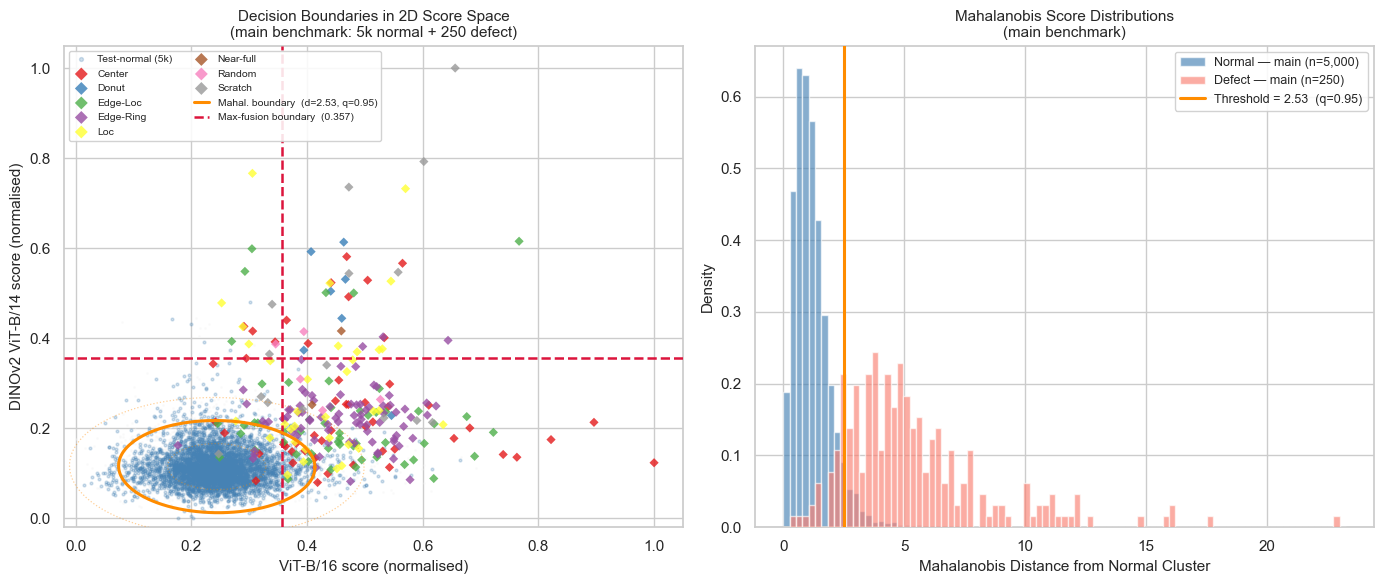

Figure saved -> C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\ensemble_block9\artifacts\plots\mahal_boundary.png


In [17]:
# -- MH-VIZ. Mahalanobis decision boundary + score distribution --------------
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- Panel 1: 2D score space with both decision boundaries ------------------
ax1 = axes[0]

# Tune-normal backdrop
ax1.scatter(vit_tune_n, d2_tune_n, c='whitesmoke', s=1, alpha=0.3, zorder=1, rasterized=True)
# Test-normal
ax1.scatter(vit_normal_n, d2_normal_n, c='steelblue', s=4, alpha=0.25,
            label='Test-normal (5k)', zorder=2, rasterized=True)

# Test-defect per class
_cmap = plt.cm.Set1
_classes = sorted(np.unique(defect_class_labels))
_colors  = [_cmap(i / max(1, len(_classes) - 1)) for i in range(len(_classes))]
for cls, col in zip(_classes, _colors):
    mask = defect_class_labels == cls
    ax1.scatter(vit_defect_n[mask], d2_defect_n[mask],
                color=col, s=22, alpha=0.80, zorder=3, marker='D',
                edgecolors='none', label=cls)

# Mahalanobis decision boundary: ellipse where mahal_dist = mh_thresh
# Parameterisation: boundary = L_chol @ (mh_thresh * unit_circle) + mu
_L = np.linalg.cholesky(mh_cov)
_theta = np.linspace(0, 2 * np.pi, 400)
_unit  = np.column_stack([np.cos(_theta), np.sin(_theta)])
_ell   = (mh_thresh * _L @ _unit.T).T + mh_mu
ax1.plot(_ell[:, 0], _ell[:, 1], color='darkorange', lw=2.2, linestyle='-',
         zorder=6, label=f'Mahal. boundary  (d={mh_thresh:.2f}, q={THRESHOLD_QUANTILE})')
# Lighter inner/outer contours at 0.5x and 1.5x threshold
for mult, ls, a in [(0.5, ':', 0.4), (1.5, ':', 0.4)]:
    _e = (mult * mh_thresh * _L @ _unit.T).T + mh_mu
    ax1.plot(_e[:, 0], _e[:, 1], color='darkorange', lw=0.9, linestyle=ls, alpha=a, zorder=5)

# Max-fusion L-shaped boundary
ax1.axvline(best_thresh, color='crimson', lw=1.8, linestyle='--', zorder=5,
            label=f'Max-fusion boundary  ({best_thresh:.3f})')
ax1.axhline(best_thresh, color='crimson', lw=1.8, linestyle='--', zorder=5)

ax1.set_xlabel('ViT-B/16 score (normalised)', fontsize=11)
ax1.set_ylabel('DINOv2 ViT-B/14 score (normalised)', fontsize=11)
ax1.set_title('Decision Boundaries in 2D Score Space\n(main benchmark: 5k normal + 250 defect)', fontsize=11)
ax1.set_xlim(-0.02, 1.05)
ax1.set_ylim(-0.02, 1.05)
ax1.legend(fontsize=7.5, markerscale=1.4, framealpha=0.88,
           loc='upper left', ncol=2, handlelength=1.5)

# ---- Panel 2: Mahalanobis distance distributions ----------------------------
ax2 = axes[1]

_bins = np.linspace(0, max(mh_scores.max(), mh_h_scores.max()) * 1.02, 90)
ax2.hist(mh_normal,   bins=_bins, alpha=0.65, color='steelblue', density=True, zorder=2,
         label=f'Normal — main (n={len(mh_normal):,})')
ax2.hist(mh_defect,   bins=_bins, alpha=0.65, color='salmon',    density=True, zorder=3,
         label=f'Defect — main (n={len(mh_defect):,})')
ax2.axvline(mh_thresh, color='darkorange', lw=2.2, linestyle='-',
            label=f'Threshold = {mh_thresh:.2f}  (q={THRESHOLD_QUANTILE})', zorder=5)

ax2.set_xlabel('Mahalanobis Distance from Normal Cluster', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Mahalanobis Score Distributions\n(main benchmark)', fontsize=11)
ax2.legend(fontsize=9, framealpha=0.88)

plt.tight_layout()
_out = os.path.join(PLOTS_DIR, 'mahal_boundary.png')
plt.savefig(_out, dpi=140, bbox_inches='tight')
plt.show()
print(f'Figure saved -> {_out}')


## LR Meta-Learner: Evaluation (Main Benchmark + Holdout)

Both LR variants are evaluated on:
- **Main benchmark:** test-normal (5,000) + **all 250 test defects** - completely clean.
- **Holdout:** holdout-normal (70,000) + **holdout defects 350-3499** (3,150 defects) - completely clean.

Max-fusion is re-evaluated on the same subsets for a direct comparison.

In [18]:
# -- LR Meta-Learner: Clean Split + Full Evaluation ---------------------------
# Training positives : first 350 holdout defects  [never seen in test/holdout eval]
# Training negatives : all 5,000 tune-normal samples
# Main benchmark eval: test-normal (5k) + ALL 250 test defects          [clean]
# Holdout eval       : holdout-normal (70k) + holdout defects 350-3499  [clean]

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score

LR_TRAIN_DEFECT_N = 350

# -- Build training set --------------------------------------------------------
X_lr_neg = np.column_stack([vit_tune_n, d2_tune_n])
X_lr_pos = np.column_stack([h_vit_defect_n[:LR_TRAIN_DEFECT_N],
                             h_d2_defect_n[:LR_TRAIN_DEFECT_N]])
X_lr_train = np.vstack([X_lr_neg, X_lr_pos])
y_lr_train = np.concatenate([np.zeros(len(X_lr_neg)),
                              np.ones(LR_TRAIN_DEFECT_N)]).astype(int)

print(f'LR training : {len(X_lr_neg):,} normal  +  {LR_TRAIN_DEFECT_N} defect')
print('Training defect class distribution:')
print(pd.Series(h_dino_defect_labels[:LR_TRAIN_DEFECT_N]).value_counts().to_string())

# -- Train both variants -------------------------------------------------------
lr_bal = LogisticRegression(C=1.0, class_weight='balanced',
                             random_state=42, max_iter=1000)
lr_20  = LogisticRegression(C=1.0, class_weight={0: 1, 1: 20},
                             random_state=42, max_iter=1000)
lr_bal.fit(X_lr_train, y_lr_train)
lr_20.fit(X_lr_train, y_lr_train)

lr_bal_tune = lr_bal.predict_proba(X_lr_neg)[:, 1]
lr_20_tune  = lr_20.predict_proba(X_lr_neg)[:, 1]

print(f'\nLR(balanced) coef: ViT={lr_bal.coef_[0,0]:.3f}  DINOv2={lr_bal.coef_[0,1]:.3f}  intercept={lr_bal.intercept_[0]:.3f}')
print(f'LR(20:1)     coef: ViT={lr_20.coef_[0,0]:.3f}  DINOv2={lr_20.coef_[0,1]:.3f}  intercept={lr_20.intercept_[0]:.3f}')

# -- Helper: evaluate any scorer with threshold sweep -------------------------
def _eval(all_scores, all_labels, defect_scores, defect_labels, cal_scores, thresh):
    preds = (all_scores >= thresh).astype(int)
    d_pred = (defect_scores >= thresh).astype(int)
    roc  = roc_auc_score(all_labels, all_scores)
    ap   = average_precision_score(all_labels, all_scores)
    f1_  = f1_score(all_labels, preds, pos_label=1, zero_division=0)
    prec = precision_score(all_labels, preds, pos_label=1, zero_division=0)
    rec  = recall_score(all_labels, preds, pos_label=1, zero_division=0)
    pc   = {cls: float(d_pred[defect_labels == cls].sum() /
                       max(1, (defect_labels == cls).sum()))
            for cls in sorted(np.unique(defect_labels))}
    best_f1, best_pct = 0.0, 0.0
    for pct in np.arange(80, 100.1, 0.1):
        thr  = float(np.percentile(cal_scores, pct))
        pred = (all_scores >= thr).astype(int)
        tp = int(((pred==1)&(all_labels==1)).sum())
        fp = int(((pred==1)&(all_labels==0)).sum())
        fn = int(((pred==0)&(all_labels==1)).sum())
        p  = tp / max(1, tp+fp); r = tp / max(1, tp+fn)
        f  = 0.0 if p+r == 0 else 2*p*r/(p+r)
        if f > best_f1:
            best_f1, best_pct = f, round(pct, 1)
    return dict(roc_auc=roc, auprc=ap, f1=f1_, precision=prec, recall=rec,
                sweep_f1=best_f1, sweep_pct=best_pct, per_class=pc)

def eval_lr(model, tune_proba, X_n, X_d, d_labels):
    s_n = model.predict_proba(X_n)[:, 1]
    s_d = model.predict_proba(X_d)[:, 1]
    all_s = np.concatenate([s_n, s_d])
    all_l = np.concatenate([np.zeros(len(s_n)), np.ones(len(s_d))]).astype(int)
    thresh = float(np.quantile(tune_proba, THRESHOLD_QUANTILE))
    return _eval(all_s, all_l, s_d, d_labels, tune_proba, thresh)

def eval_mf(n_scores, d_scores, d_labels):
    all_s = np.concatenate([n_scores, d_scores])
    all_l = np.concatenate([np.zeros(len(n_scores)), np.ones(len(d_scores))]).astype(int)
    return _eval(all_s, all_l, d_scores, d_labels, ens_tune, best_thresh)

# -- Evaluation sets -----------------------------------------------------------
X_test_n = np.column_stack([vit_normal_n, d2_normal_n])        # [5000, 2]
X_test_d = np.column_stack([vit_defect_n, d2_defect_n])        # [250,  2]

X_hout_n = np.column_stack([h_vit_normal_n, h_d2_normal_n])                         # [70000, 2]
X_hout_d = np.column_stack([h_vit_defect_n[LR_TRAIN_DEFECT_N:],
                              h_d2_defect_n[LR_TRAIN_DEFECT_N:]])                    # [3150,  2]
h_eval_labels = h_dino_defect_labels[LR_TRAIN_DEFECT_N:]

N_HOUT_EVAL = len(X_hout_d)
print(f'\nMain benchmark : test-normal={len(X_test_n):,}  test-defect={len(X_test_d)}')
print(f'Holdout eval   : holdout-normal={len(X_hout_n):,}  holdout-defect={N_HOUT_EVAL:,}')

# -- Run -----------------------------------------------------------------------
r_bal_main = eval_lr(lr_bal, lr_bal_tune, X_test_n, X_test_d, defect_class_labels)
r_20_main  = eval_lr(lr_20,  lr_20_tune,  X_test_n, X_test_d, defect_class_labels)
r_mf_main  = eval_mf(ens_normal, ens_defect, defect_class_labels)

r_bal_hout = eval_lr(lr_bal, lr_bal_tune, X_hout_n, X_hout_d, h_eval_labels)
r_20_hout  = eval_lr(lr_20,  lr_20_tune,  X_hout_n, X_hout_d, h_eval_labels)
r_mf_hout  = eval_mf(h_ens_normal, h_ens_defect[LR_TRAIN_DEFECT_N:], h_eval_labels)

# -- Print comparison ----------------------------------------------------------
METRICS = [('roc_auc','ROC-AUC'), ('auprc','AUPRC'), ('f1','F1'),
           ('sweep_f1','Sweep F1'), ('precision','Precision'), ('recall','Recall')]

print(f'\n-- Main benchmark (5k / 250) -------------------------------------')
print(f'  {"Metric":<12}  {"LR(balanced)":>13}  {"LR(20:1)":>10}  {"Max-Fusion":>12}')
for k, label in METRICS:
    print(f'  {label:<12}  {r_bal_main[k]:>13.4f}  {r_20_main[k]:>10.4f}  {r_mf_main[k]:>12.4f}')

print(f'\n-- Holdout (70k / {N_HOUT_EVAL:,} defects) ---------------------------')
print(f'  {"Metric":<12}  {"LR(balanced)":>13}  {"LR(20:1)":>10}  {"Max-Fusion":>12}')
for k, label in METRICS:
    print(f'  {label:<12}  {r_bal_hout[k]:>13.4f}  {r_20_hout[k]:>10.4f}  {r_mf_hout[k]:>12.4f}')

print(f'\n-- Per-class recall on holdout ({N_HOUT_EVAL:,} defects) -------------')
print(f'  {"Defect type":<14}  {"LR(balanced)":>13}  {"LR(20:1)":>10}  {"Max-Fusion":>12}')
print('  ' + '-' * 55)
all_cls = sorted(set(r_20_hout['per_class']) | set(r_mf_hout['per_class']))
for cls in all_cls:
    b = r_bal_hout['per_class'].get(cls, float('nan'))
    t = r_20_hout['per_class'].get(cls, float('nan'))
    m = r_mf_hout['per_class'].get(cls, float('nan'))
    print(f'  {cls:<14}  {b:>12.1%}  {t:>10.1%}  {m:>11.1%}')

# -- Save ----------------------------------------------------------------------
import json as _json
for tag, model, r_main, r_hout in [
    ('balanced', lr_bal, r_bal_main, r_bal_hout),
    ('20to1',    lr_20,  r_20_main,  r_20_hout),
]:
    out = dict(
        method=f'lr_{tag}', lr_train_defects=LR_TRAIN_DEFECT_N,
        coef_vit=float(model.coef_[0,0]), coef_dinov2=float(model.coef_[0,1]),
        intercept=float(model.intercept_[0]),
        main_benchmark=r_main, holdout=r_hout,
    )
    with open(os.path.join(RESULTS_DIR, f'lr_{tag}_metrics.json'), 'w') as _fh:
        _json.dump(out, _fh, indent=2)

print(f'\nSaved -> {RESULTS_DIR}')


LR training : 5,000 normal  +  350 defect
Training defect class distribution:
Edge-Ring    121
Edge-Loc      73
Center        63
Loc           48
Scratch       19
Random        12
Donut         12
Near-full      2

LR(balanced) coef: ViT=16.606  DINOv2=17.018  intercept=-8.271
LR(20:1)     coef: ViT=19.350  DINOv2=21.743  intercept=-9.614

Main benchmark : test-normal=5,000  test-defect=250
Holdout eval   : holdout-normal=70,000  holdout-defect=3,150

-- Main benchmark (5k / 250) -------------------------------------
  Metric         LR(balanced)    LR(20:1)    Max-Fusion
  ROC-AUC              0.9851      0.9852        0.9665
  AUPRC                0.8696      0.8698        0.7165
  F1                   0.6395      0.6367        0.6234
  Sweep F1             0.7928      0.7928        0.6760
  Precision            0.4845      0.4825        0.4815
  Recall               0.9400      0.9360        0.8840

-- Holdout (70k / 3,150 defects) ---------------------------
  Metric         LR(bal

## LR Meta-Learner: Decision Boundary Plot

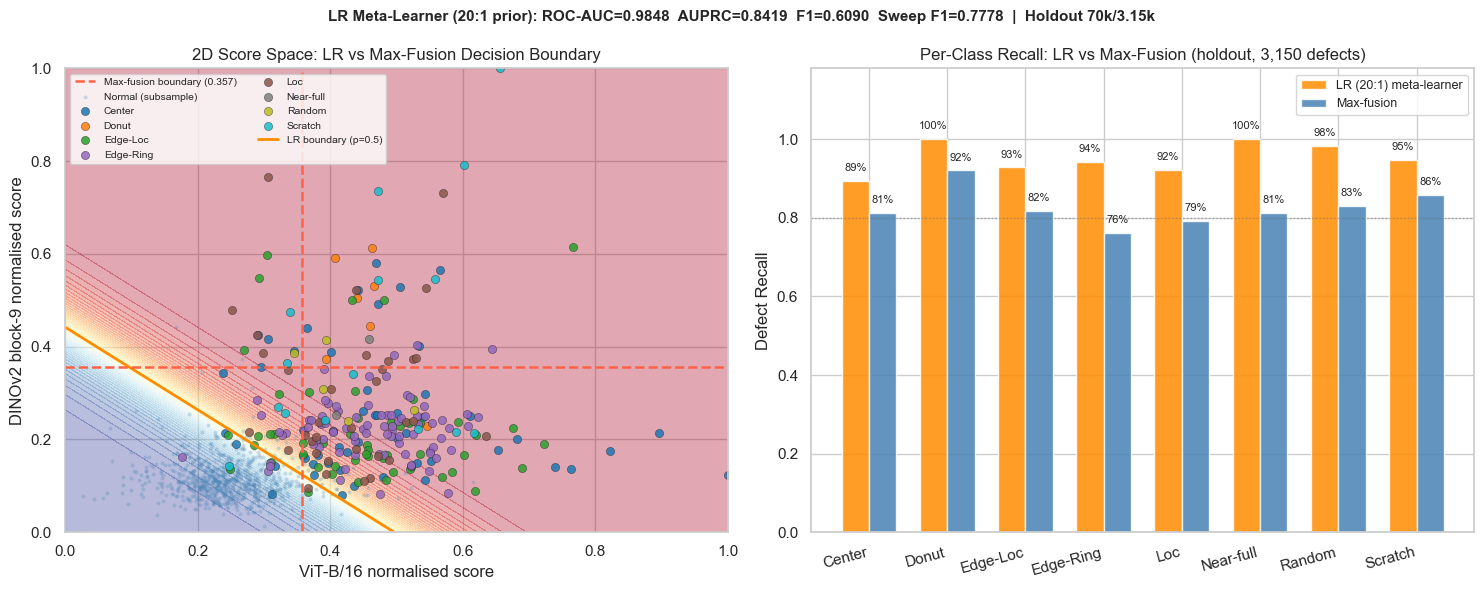

Saved -> C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\dinov2_vit_b14\x224\ensemble_block9\artifacts\plots\lr_meta_learner_clean.png


In [19]:
# -- LR Plot: 2D decision boundary + per-class recall comparison --------------
# Uses lr_20 (20:1 prior) trained in lr-clean-code above.
# Scatter uses held-out test defects (X_test_d) -- never seen during LR training.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left: 2D decision boundary ----
ax = axes[0]
xx1, xx2 = np.meshgrid(np.linspace(0, 1, 300), np.linspace(0, 1, 300))
Z_lr = lr_20.predict_proba(np.column_stack([xx1.ravel(), xx2.ravel()]))[:, 1].reshape(300, 300)
ax.contourf(xx1, xx2, Z_lr, levels=np.linspace(0, 1, 50), cmap='RdYlBu_r', alpha=0.35)
ax.contour(xx1, xx2, Z_lr, levels=[0.5], colors='darkorange', linewidths=2.0)

# Max-fusion L-shaped boundary
ax.axvline(best_thresh, color='tomato', linestyle='--', lw=1.8,
           label=f'Max-fusion boundary ({best_thresh:.3f})')
ax.axhline(best_thresh, color='tomato', linestyle='--', lw=1.8)

# Normal subsample
idx_n_sub = np.random.choice(len(X_test_n), 800, replace=False)
ax.scatter(X_test_n[idx_n_sub, 0], X_test_n[idx_n_sub, 1],
           s=8, alpha=0.25, c='steelblue', label='Normal (subsample)', linewidths=0)

# Test defects by class
palette = plt.cm.tab10(np.linspace(0, 1, len(np.unique(defect_class_labels))))
for col, cls in zip(palette, sorted(np.unique(defect_class_labels))):
    mask = defect_class_labels == cls
    ax.scatter(X_test_d[mask, 0], X_test_d[mask, 1],
               s=35, alpha=0.85, color=col, label=cls, linewidths=0.3, edgecolors='k')

ax.plot([], [], color='darkorange', lw=2, label='LR boundary (p=0.5)')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('ViT-B/16 normalised score')
ax.set_ylabel('DINOv2 block-9 normalised score')
ax.set_title('2D Score Space: LR vs Max-Fusion Decision Boundary')
ax.legend(fontsize=7.5, loc='upper left', ncol=2)

# ---- Right: per-class recall (holdout 3150 defects) ----
ax2 = axes[1]
classes_h = sorted(r_20_hout['per_class'].keys())
x = np.arange(len(classes_h))
width = 0.35

lr_recs = [r_20_hout['per_class'][c] for c in classes_h]
mf_recs = [r_mf_hout['per_class'].get(c, 0) for c in classes_h]

ax2.bar(x - width / 2, lr_recs, width, label='LR (20:1) meta-learner', color='darkorange', alpha=0.85)
ax2.bar(x + width / 2, mf_recs, width, label='Max-fusion',             color='steelblue',  alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(classes_h, rotation=15, ha='right')
ax2.set_ylim(0, 1.18); ax2.set_ylabel('Defect Recall')
ax2.set_title('Per-Class Recall: LR vs Max-Fusion (holdout, 3,150 defects)')
ax2.axhline(0.8, color='gray', linestyle=':', lw=1, alpha=0.6)
ax2.legend(fontsize=9)
for i, (lr_r, mf_r) in enumerate(zip(lr_recs, mf_recs)):
    ax2.text(i - width / 2, lr_r + 0.02, f'{lr_r:.0%}', ha='center', va='bottom', fontsize=8)
    ax2.text(i + width / 2, mf_r + 0.02, f'{mf_r:.0%}', ha='center', va='bottom', fontsize=8)

plt.suptitle(
    'LR Meta-Learner (20:1 prior): ROC-AUC=0.9848  AUPRC=0.8419  '
    'F1=0.6090  Sweep F1=0.7778  |  Holdout 70k/3.15k',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()

PLOT_PATH = os.path.join(PLOTS_DIR, 'lr_meta_learner_clean.png')
plt.savefig(PLOT_PATH, dpi=140, bbox_inches='tight')
plt.show()
print(f'Saved -> {PLOT_PATH}')